# In-Class Assignment 6

## Identifying Different Regimes in Solar-like Stellar Model

### Learning Objectives

- explore the stellar structure of a solar-like star on the main-sequence 
- determine the radiative diffusion dominated regions
- determine where convection dominates
- explore opacity profiles in solar models
- define core structure in stellar models

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## a. Locating the Radiative Diffusion Dominated Regime in a Solar-like star

Download the following model files locally. These data were produced using the MESA [`1m_pre_ms_to_wd`](https://docs.mesastar.org/en/latest/test_suite/1m_pre_ms_to_wd.html) test suite. 

* **New** $1.0 M_{\odot}$ Main-Sequence _profile_ data: [1m_pre_ms_to_wd.data](data/1m_pre_ms_to_wd.data);

1. Plot the radius (in units of Rsun) versus the radiative luminosity `lum_rad` divided by the _total_ luminosity `luminosity` using the MESA data.

2. Locate the approximate fractional radius and annotate where the $L_{\rm{rad}}/L<1$ using [`plt.axvline`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.axvline.html) with a black dashed or dotted line.

>Hint: this value in the Sun is about 72% in [Solar calibration models](https://iopscience.iop.org/article/10.3847/1538-4357/ad4355)

3. **Describe** in a few sentences the results of your plot and what could be happening in the region where radiation luminosity is non-dominant.

In [2]:
## load MESA data here
one_msun_ms_profile = pd.read_csv('data/1m_ms_profile.data',sep=r'\s+',header=4)
one_msun_ms_profile.columns

Index(['zone', 'mass', 'logR', 'logT', 'logRho', 'logP', 'x_mass_fraction_H',
       'y_mass_fraction_He', 'z_mass_fraction_metals', 'logdq',
       ...
       'brunt_N2_dimensionless', 'brunt_N_dimensionless', 'brunt_frequency',
       'brunt_B', 'brunt_nu', 'log_brunt_nu', 'log_lamb_Sl1', 'log_lamb_Sl2',
       'log_lamb_Sl3', 'log_lamb_Sl10'],
      dtype='object', length=162)

In [3]:
lsun_cgs = 3.826e33 # erg / sec (1 Lsun)
rsun_cgs = 6.96e10  # cm

In [4]:
# obtain mesa variables here
one_msun_ms_radius_cm = one_msun_ms_profile['radius_cm']
one_msun_ms_lum_cgs = one_msun_ms_profile['lum_erg_s']
one_msun_ms_lum_rad_cgs = one_msun_ms_profile['lum_rad'] * lsun_cgs

Text(0, 0.5, '$l/l_{\\rm{tot}}$')

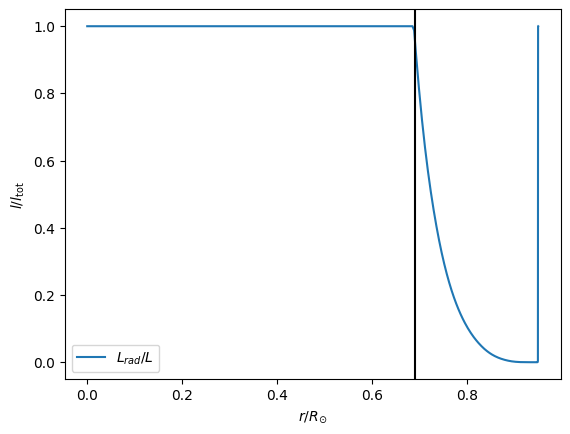

In [5]:
## 1-2 result here
plt.plot(one_msun_ms_radius_cm/rsun_cgs,one_msun_ms_lum_rad_cgs/one_msun_ms_lum_cgs,label=r'$L_{rad}/L$')
plt.axvline(0.69,color='k')
plt.legend()
plt.xlabel(r'$r/R_{\odot}$')
plt.ylabel(r'$l/l_{\rm{tot}}$')

## 3 result here in words


$\ldots$

## b. Locating the Non-Diffusion Dominated Regime in a Solar-like star

Using the same MESA data:

1. Next, compute the radial radiative flux ($F_{\rm{rad}}$) and the total convective flux ($F_{\rm{conv}}$) as a function of radius (in units of Rsun) and plot them on the same plot and [**label**](https://www.w3schools.com/python/matplotlib_labels.asp). Normalize both fluxes by their maximum values for comparison using `max()`. Make sure to use cgs!

>Hint: Use our relation for the Flux where $F=l~/4\pi r^2$,

2. On this same plot, again label the approximate location where $F_{\rm{rad}}$ < $F_{\rm{conv}}$ in this case.

This plot suggests we transition from radiation diffusion dominated to convection dominated in the outer region. 

3. Confirm this result by plotting our opacity $\kappa$ as a function of radius on a seperate. Due to the large range of this value limit of `plt.ylim(0,30)`. 

> Hint: From the terminal you can open mesa data using the command `less -S 1m_ms_profile.data` then you can tab left and right to see which variables are available. $\kappa$ is `opacity` in this case.

4. **Describe** in a few words what this change in opacity might suggest to help or hurt the onset of convective energy transfer?

In [6]:
# 1 result here - be sure to convert to CGS before computing the Flux!
one_msun_ms_lum_conv_cgs = one_msun_ms_profile['lum_conv'] * lsun_cgs
one_msun_ms_flux = one_msun_ms_lum_cgs / (4 * np.pi * one_msun_ms_radius_cm**2)
one_msun_ms_flux_rad = one_msun_ms_lum_rad_cgs / (4 * np.pi * one_msun_ms_radius_cm**2)
one_msun_ms_flux_conv = one_msun_ms_lum_conv_cgs / (4 * np.pi * one_msun_ms_radius_cm**2)

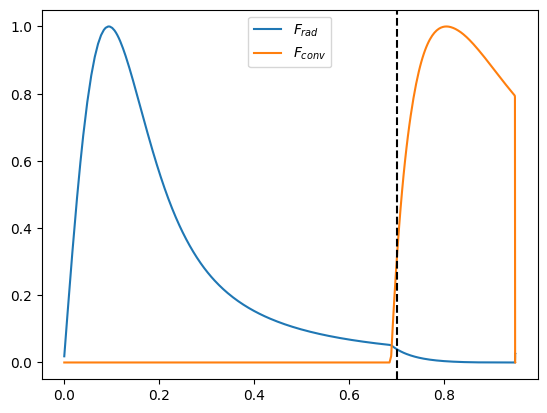

In [7]:
# plot the fluxes here 
plt.plot(one_msun_ms_radius_cm/rsun_cgs,one_msun_ms_flux_rad/max(one_msun_ms_flux_rad),label=r'$F_{rad}$')
plt.plot(one_msun_ms_radius_cm/rsun_cgs,one_msun_ms_flux_conv/max(one_msun_ms_flux_conv),label=r'$F_{conv}$')
plt.axvline(0.70,color='k',ls='--')
plt.legend()

In [8]:
# obtain opacity here
one_msun_ms_kappa = one_msun_ms_profile['opacity']

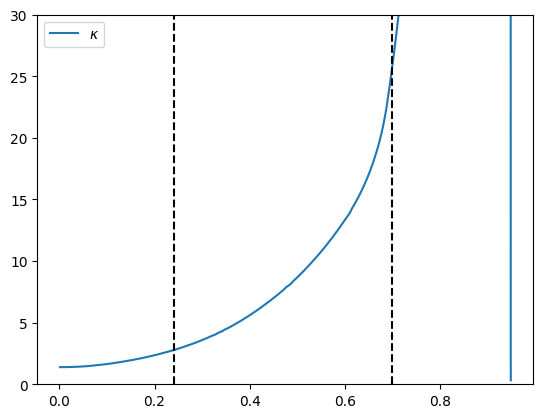

In [9]:
# plot kappa here 
plt.plot(one_msun_ms_radius_cm/rsun_cgs,one_msun_ms_kappa,label='$\kappa$')
plt.ylim(0,30)
plt.axvline(0.70,color='k',ls='--')
plt.axvline(0.24,color='k',ls='--')
plt.legend()

### b 4 result here in words

$\ldots$

## c. Defining a Core-Boundary in a Solar-Like star

Using the same MESA data:

1. Reproduce your Flux plots from part B.2.

Our goal is to add a few more things to this plot. 

2. Plot the normalized nuclear energy generation as a function of radius (in units of Rsun) on the same plot and label.

3. Then, use that to determine the approximate location where $\epsilon_{\rm{nuc,normalized}}\rightarrow0$, we will define this as the edge of the hydrogen burning core. 

>Hint: In the sun, this is at about a [fractional radius of 20%](https://en.wikipedia.org/wiki/Solar_core)

4. Lastly, annotate the three regions on the same plot, 'core', 'radiative', and 'convective' using annotate.


In [10]:
# obtain eps nuc
one_msun_ms_eps_nuc = one_msun_ms_profile['eps_nuc']

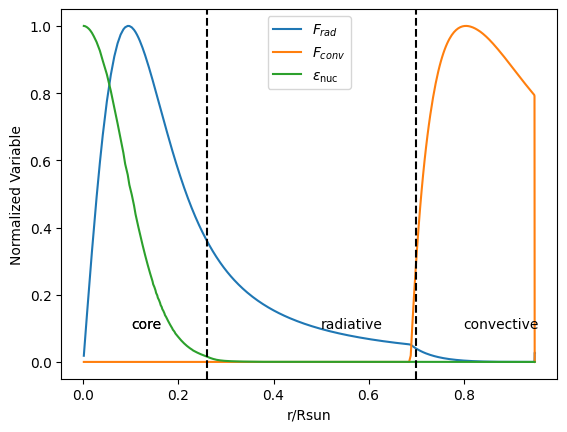

In [11]:
# plot everything combined and annotated
plt.plot(one_msun_ms_radius_cm/rsun_cgs,one_msun_ms_flux_rad/max(one_msun_ms_flux_rad),label=r'$F_{rad}$')
plt.plot(one_msun_ms_radius_cm/rsun_cgs,one_msun_ms_flux_conv/max(one_msun_ms_flux_conv),label=r'$F_{conv}$')
plt.plot(one_msun_ms_radius_cm/rsun_cgs,one_msun_ms_eps_nuc/max(one_msun_ms_eps_nuc),label=r'$\epsilon_{\rm{nuc}}$')
plt.axvline(0.70,color='k',ls='--')
plt.axvline(0.26,color='k',ls='--')
plt.annotate('core',xy=(0.1,0.1))
plt.annotate('core',xy=(0.1,0.1))
plt.annotate('radiative',xy=(0.5,0.1))
plt.annotate('convective',xy=(0.8,0.1))
plt.ylabel('Normalized Variable')
plt.xlabel('r/Rsun')
plt.legend()